# Project 3: Applied Demonstration of an AI Modeling Method

**Synthetic Data**

The specific AI modeling method selected is logistic regression. With logistic regression, attempts to stress overfitting with small dataset and large features are made to demonstrate the limitations of logistic regression. Using L1 regularization (Lasso), the regularized model demonstrates the importance in regularizing models.

The synthetic dataset is created with a small number of observations (100) and a large number of features (1000). A small subset of the features are truly predictive of the target variable, which is binary, and the majority of .features are random noise, designed to confuse the model and induce overfitting

In [26]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Parameters for the synthetic dataset
n_samples = 100 # Relatively small # of observations
n_features = 1000 # Relatively large number of features 10x
n_informative = 10 # Only 10 features are actually informative
random_state = 42

# Generating the synthetic dataset
X, y = make_classification (
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=random_state
)

print(f"Shape of features (X); {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

#Checking binary targets of y
print(f"Class distribution in y: {np.bincount(y)}")
print(f"Class distribution in y_train: {np.bincount(y_train)}")
print(f"Class distribution in y_test: {np.bincount(y_test)}")
print(f"{y[:10]}")

Shape of features (X); (100, 1000)
Shape of target (y): (100,)
Train set shape: (70, 1000)
Test set shape: (30, 1000)
Class distribution in y: [49 51]
Class distribution in y_train: [32 38]
Class distribution in y_test: [17 13]
[1 1 0 0 0 1 1 1 0 0]


Execution time: 0.2464 seconds
Training Accuracy: 1.0000
Test Accuracy: 0.6667


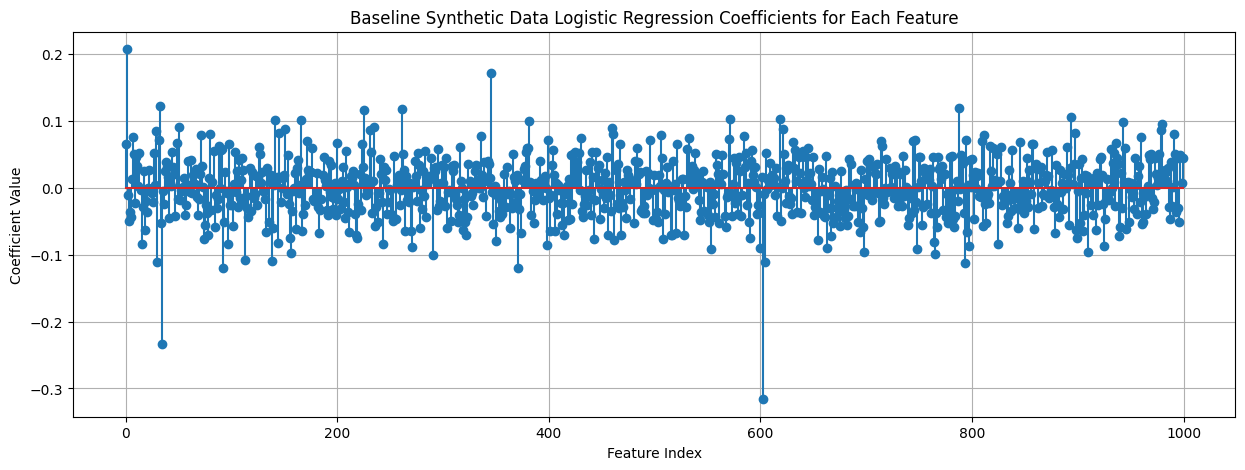

Execution time: 0.2133 seconds


In [27]:
import time

start = time.time()
#Training and Evaluating Logistic Regression
#Expectation: High Accuracy on training set with significantly lower accuracy on the unseen test data
#Simple Model (default C parameter) to demonstrate overfitting without regularizaiton
model = LogisticRegression(solver='liblinear', random_state=random_state, max_iter=1000)
model.fit(X_train,y_train)

total = sum(range(10_000_000))

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")


start = time.time()
#Evaluating model on training set
y_train_pred = model.predict(X_train)
train_accuracy=accuracy_score(y_train,y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Evaluating model on the test set
y_test_pred=model.predict(X_test)
test_accuracy=accuracy_score(y_test,y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

#Plotting the coefficients to see how the model relies on many features
plt.figure(figsize=(15,5))
plt.stem(model.coef_[0])
plt.title('Baseline Synthetic Data Logistic Regression Coefficients for Each Feature')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

The training accuracy is 100% while the test accuracy is 67%. The regression model is overfit to the training data, using the noise. Many non-zero weights are assigned to non-informative features.

Execution time: 0.0076 seconds
Regularized Training Accuracy: 0.8857
Regularized Test Accuracy: 0.7667


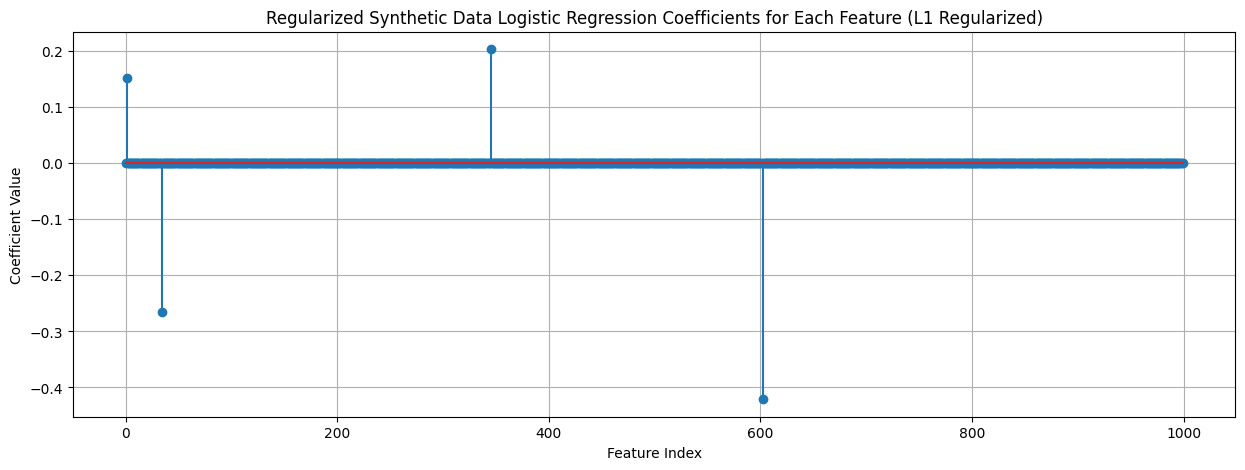

Execution time: 0.2004 seconds


In [28]:
start = time.time()
#Regularization with Lasso, which encourages sparsity in the coefficients
#Lasso corresponds to feature selection and reducing the impact of noisy features
#C parameter controls the inverse of regularization strength
model_regularized = LogisticRegression(solver='liblinear',penalty='l1',C=0.1, random_state=random_state,max_iter=1000)
model_regularized.fit(X_train,y_train)

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

start = time.time()
#Evaluate regularized model on the training set
y_train_pred_reg=model_regularized.predict(X_train)
train_accuracy_reg = accuracy_score(y_train,y_train_pred_reg)
print(f"Regularized Training Accuracy: {train_accuracy_reg:.4f}")

#Evaluating regularized model on test set
y_test_pred_reg = model_regularized.predict(X_test)
test_accuracy_reg = accuracy_score(y_test,y_test_pred_reg)
print(f"Regularized Test Accuracy: {test_accuracy_reg:.4f}")

#Plotting the coefficients of the regularized model
plt.figure(figsize=(15,5))
plt.stem(model_regularized.coef_[0])
plt.title('Regularized Synthetic Data Logistic Regression Coefficients for Each Feature (L1 Regularized)')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

With regularization, the test accuracy has improved and the coefficient plot shows that many coefficients are variable have been driven to zero. As we made the model, we know that 10 features are informative. We see that there are only four features in our regularized logistic regression model, showing that while regularization is important, too much can cause underfitting.

Interpretation and Insight: Overfitting occurs with too many features relative to observations and regularization can migitage this issue and lead to improved test accuracy. However, regularization can also cause underfitting and even disregard certain necessary features. The best logistic regression models must find the right numbe of features for the most accurate data.


From the initial training set without regularization, logistic regression is great and yield high accuracy if trying to predict a data point within it's training dataset. However, from the test accuracy vs the training accuracy, we can understand that too many features and too little features in relative to the observations can cause overfitting and underfitting the model for similair data outside of the trained data.

**Real-World Data**

To demonstrate the limitations of logistic regression of overfitting due to noise, we choose a high featured dataset. This dataset has ~3.3 million anonymized features from a URL.

In [31]:
#imports
import os
from google.colab import drive
import pandas as pd

In [32]:
#Connecting to drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Wu Colab Notebooks/Project 3: Method Demo"

#List files
print("Files in shared data folder:", os.listdir(data_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in shared data folder: ['combined+cycle+power+plant.zip', 'Folds5x2_pp.ods', 'Readme.txt', 'Readme.txt_', 'Folds5x2_pp.xlsx', 'PowerPlants.csv', 'url+reputation.zip', 'Untitled spreadsheet - Day 0.csv', 'day 0 .csv', 'day 1.csv', 'day 100.csv', 'day 120.csv']


In [33]:
#Construct the full path to the 'day 0 . csv' file
csv_file_path = data_path + "/day 0 .csv"

# Load the CSV file into a pandas DataFrame
df_day0 = pd.read_csv(csv_file_path, header=None)
print(f"Shape of df_day0: {df_day0.shape}")
print(f"First 5 rows of day 0 . csv loaded as a standard CSV:")
display(df_day0.head())

Shape of df_day0: (16000, 1)
First 5 rows of day 0 . csv loaded as a standard CSV:


,0
0,-1 4:0.0788382 5:0.124138 6:0.117647 11:0.4285...
1,-1 2:1 4:0.165975 5:0.103448 6:0.176471 11:0.2...
2,-1 2:1 4:0.0912863 5:0.144828 6:0.117647 10:1 ...
3,-1 4:0.0580913 5:0.0896552 6:0.176471 11:0.142...
4,+1 2:1 4:0.0788382 5:0.131034 6:0.117647 10:1 ...


In [34]:
#Import more
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import os

#Extract the SVMLight formatted strings from the DataFrame
svmlight_data_from_df = df_day0[0].str.strip().tolist()

# Join the list of strings into a single string with newline characters
svmlight_data_string = "\n".join(svmlight_data_from_df)

#Create a temporary file to write the SVMLight data
# Workaround to load_svmlight_file expecting a file-like object or a path to a plain text file, which our data is currently not as it's in csv
tmp_svmlight_file_path = "/tmp/day0_svmlight_data.txt"
with open(tmp_svmlight_file_path, "w") as f:
  f.write(svmlight_data_string)

#Load the SVMLight data from the temporary file
# The number of features is 3231949 according to dataset given
n_features_expected = 3231949
X_sparse, y_svmlight = load_svmlight_file(tmp_svmlight_file_path, n_features=3231958)

print(f"Shape of features (X_sparse): {X_sparse.shape}")
print(f"Shape of target (y_svmlight): {y_svmlight.shape}")
print(f"Unique target values (before conversion): {np.unique(y_svmlight)}")

# Convert SVMLight target labels (-1, 1) to (0,1) for scikit-learn Logistic Regression
y_url = np.where(y_svmlight == -1, 0, y_svmlight)

print(f"Unique target values (after conversion): {np.unique(y_url)}")

#Check if y_url contains at least two classes for binary classification
if len(np.unique(y_url)) < 2:
  raise ValueError("Conversion Error")

Shape of features (X_sparse): (16000, 3231958)
Shape of target (y_svmlight): (16000,)
Unique target values (before conversion): [-1.  1.]
Unique target values (after conversion): [0. 1.]


In [35]:
  #Split the dataset into training and testing sets
  X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
      X_sparse, y_url, test_size=0.3, random_state= 42, #stratify=y_url #Stratify to maintain class balance
  )

  print(f"Train set shape (X_train_url): {X_train_url.shape}")
  print(f"Test set shape (X_test_url): {X_test_url.shape}")

Train set shape (X_train_url): (11200, 3231958)
Test set shape (X_test_url): (4800, 3231958)


Limitations of Logistic Regression
1. Computational Intensity

How long does it take for the model to be createda?

2. Overfitting

How many features does the model fit to?

3. Poor Generalization

Is the training accuracy significantly higher than the test accuracy?

In [36]:
import time

start = time.time()

#Initialize and train the Logistic Regression model with default C (default regularization)
# Use 'liblinear' for small dataset
model_url_baseline = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, C=1.0)

print("Training baseline Logistic Regression model...")
model_url_baseline.fit(X_train_url, y_train_url)
print("Baseline model training complete.")

total = sum(range(10_000_000))

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Training baseline Logistic Regression model...
Baseline model training complete.
Execution time: 7.6678 seconds


In [37]:
start = time.time()

#Count non-zero coefficients to see how many features the model is using
non_zero_coefs_baseline=np.sum(model_url_baseline.coef_[0] !=0)
print(f"Number of non-zero coefficients (Baseline): {non_zero_coefs_baseline}")

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Number of non-zero coefficients (Baseline): 58160
Execution time: 0.0068 seconds


Evaluating Performance on Day 1, 100, and 120

In [38]:
start = time.time()
# Construct the full path to 'day 1.csv', 'day 100.csv', ' day 120.csv' files
csv_file_path_1 = data_path + "/day 1.csv"
csv_file_path_100 = data_path + "/day 100.csv"
csv_file_path_120 = data_path + "/day 120.csv"

#Load the CSV files into a pandas DataFrame
df_day1=pd.read_csv(csv_file_path_1, header=None)
df_day100=pd.read_csv(csv_file_path_100, header=None)
df_day120=pd.read_csv(csv_file_path_120, header=None)

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Execution time: 0.8857 seconds


In [39]:
start = time.time()
print(f"Shape of df_day1: {df_day1.shape}")
print("First 5 rows of day 1.csv loaded as a standard CSV:")
display(df_day1.head())

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Shape of df_day1: (18232, 1)
First 5 rows of day 1.csv loaded as a standard CSV:


,0
0,-1 4:0.0788382 5:0.124138 6:0.117647 11:0.2857...
1,-1 2:1 4:0.0705394 5:0.110345 6:0.117647 10:1 ...
2,-1 4:0.0456432 5:0.0689655 6:0.117647 10:1 11:...
3,+1 4:0.0373444 5:0.062069 6:0.0588235 21:0.000...
4,-1 2:1 4:0.0954357 5:0.158621 6:0.117647 9:1 1...


Execution time: 0.0130 seconds


In [40]:
start = time.time()
print(f"Shape of df_day100: {df_day100.shape}")
print("First 5 rows of day 100.csv loaded as a standard CSV:")
display(df_day100.head())

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Shape of df_day100: (17835, 1)
First 5 rows of day 100.csv loaded as a standard CSV:


,0
0,+1 4:0.0290456 5:0.0482759 6:0.0588235 11:0.14...
1,+1 2:1 4:0.0539419 5:0.0896552 6:0.0588235 10:...
2,-1 4:0.0705394 5:0.110345 6:0.117647 11:0.7142...
3,-1 2:1 4:0.0746888 5:0.117241 6:0.117647 9:1 1...
4,-1 2:1 4:0.19917 5:0.131034 6:0.176471 11:0.28...


Execution time: 0.0137 seconds


In [41]:
start = time.time()
print(f"Shape of df_day120: {df_day120.shape}")
print("First 5 rows of day 120.csv loaded as a standard CSV:")
display(df_day120.head())

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Shape of df_day120: (18409, 1)
First 5 rows of day 120.csv loaded as a standard CSV:


,0
0,+1 4:0.0373444 5:0.062069 6:0.0588235 21:0.142...
1,+1 4:0.0705394 5:0.117241 6:0.0588235 21:0.142...
2,+1 4:0.0705394 5:0.117241 6:0.0588235 21:0.142...
3,+1 4:0.0207469 5:0.0344828 6:0.0588235 21:0.14...
4,+1 4:0.0580913 5:0.0965517 6:0.0588235 21:0.14...


Execution time: 0.0135 seconds


In [48]:
import re #Import regex module
start = time.time()
#apply strip() to each line to remove leading/trailing whitespace
svmlight_data_from_df_day1 = df_day1[0].astype(str).str.strip().tolist()
#Enhanced filtering logic
svmlight_data_from_df_day1_filtered = []
#Regex to match a valid SVMLight feature: e.g., "1:0.5", "10:1"
#Ensure format is digits:non-white-space-characters
feature_format_re=re.compile(r'^\d+:\S+$')

for line in svmlight_data_from_df_day1:
  if not line: #Skip completely empty lines after stripping
    continue

  parts = line.split()

  #Ensure there's a label and at least one feature part, and the label is valid
  if len(parts) >= 2 and parts[0] in ['-1','1','+1']:
    all_features_conform = True
    for feature_part in parts[1:]:
      if not feature_format_re.match(feature_part):
        all_features_conform = False
        break
    if all_features_conform:
        svmlight_data_from_df_day1_filtered.append(line)
    #Else: line is malformed (e.g., only label, or invalid label, or malformed feature part)

print(f"Number of lines after filtering: {len(svmlight_data_from_df_day1_filtered)}")

#Join the list of strings into a single string with newline characters
svmlight_data_string_day1= "\n".join(svmlight_data_from_df_day1_filtered)

#Create a temporary file to write the SVMLight data
# Workaround to load_svmlight_file expecting a file-like object or a path to a plain text file, which our data is currently not as it's in csv
tmp_svmlight_file_path_day1 = "/tmp/day1_svmlight_data.txt"
with open(tmp_svmlight_file_path_day1, "w") as f:
  f.write(svmlight_data_string_day1)

  #Load the svmlight data from temporary file for day 1
  # use same n_features as expected
  if 'n_features_expected' not in locals():
    n_features_expected = 3231955
    #Has 6 more features?
  X_day1_sparse, y_day1_svmlight = load_svmlight_file(tmp_svmlight_file_path_day1, n_features=3231958)

  print(f"\nShape of features (X_day1_sparse): {X_day1_sparse.shape}")
  print(f"Shape of target (y_day1_svmlight): {y_day1_svmlight.shape}")
  print(f"Unique target values (before conversion) for day 1: {np.unique(y_day1_svmlight)}")

  #Convert SVMLight target labels (-1,1) to (0,1) for scikit-learn LogisticRegression
  y_day1 = np.where(y_day1_svmlight == -1, 0, y_day1_svmlight)

  print(f"Unique target values (after conversion) for day 1: {np.unique(y_day1)}")

  #Check if y_day1 contains at least two classes for binary classification
  if len(np.unique(y_day1)) < 2:
    print("Warning: The target variable y_day1 contains less than two unique classes. Evaluating on a single-class test set.")
  else:
      print("Target variable y_day1 contains two unique classes, proceeding with evaluation.")

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Number of lines after filtering: 18231

Shape of features (X_day1_sparse): (18231, 3231958)
Shape of target (y_day1_svmlight): (18231,)
Unique target values (before conversion) for day 1: [-1.  1.]
Unique target values (after conversion) for day 1: [0. 1.]
Target variable y_day1 contains two unique classes, proceeding with evaluation.
Execution time: 8.3176 seconds


In [43]:
# Construct the full path to the 'day 100.csv' file, same thing as preprocessing day 1.csv
start = time.time()

svmlight_data_from_df_day100 = df_day100[0].astype(str).str.strip().tolist()
svmlight_data_from_df_day100_filtered = []
feature_format_re = re.compile(r'^\d+:\S+$')

for line in svmlight_data_from_df_day100:
  if not line: #Skip completely empty lines after stripping
    continue
  parts = line.split()
  if len(parts) >= 2 and parts[0] in ['-1','1','+1']:
    all_features_conform = True
    for feature_part in parts[1:]:
      if not feature_format_re.match(feature_part):
        all_features_conform = False
        break
    if all_features_conform:
      svmlight_data_from_df_day100_filtered.append(line)

print(f"Number of lines after filtering: {len(svmlight_data_from_df_day100_filtered)}")
svmlight_data_string_day100 = "\n".join(svmlight_data_from_df_day100_filtered)

tmp_svmlight_file_path_day100 = "/tmp/day100_svmlight_data.txt"
with open(tmp_svmlight_file_path_day100, "w") as f:
  f.write(svmlight_data_string_day100)

if 'n_features_expected' not in locals():
  n_features_expected = 3231958 #7 more
X_day100_sparse,y_day100_svmlight = load_svmlight_file(tmp_svmlight_file_path_day100, n_features=3231958)

print(f"\nShape of features (X_day100_sparse): {X_day100_sparse.shape}")
print(f"Shape of target (y_day100_svmlight): {y_day100_svmlight.shape}")
print(f"Unique target values (before conversion) for day 100: {np.unique(y_day100_svmlight)}")

#Convert SVMLight target labels (-1,1) to (0,1) for scikit-learn LogisticRegression
y_day100 = np.where(y_day100_svmlight == -1, 0, y_day100_svmlight)

print(f"Unique target values (after conversion) for day 100: {np.unique(y_day100)}")
if len(np.unique(y_day100)) <2:
  print("Warning: The target variable y_day100 contains less than two unique classes. Evaluating on a single-class test set.")
else:
  print("Target variable y_day100 contains two unique classes, proceeding with evaluation.")

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Number of lines after filtering: 17834

Shape of features (X_day100_sparse): (17834, 3231958)
Shape of target (y_day100_svmlight): (17834,)
Unique target values (before conversion) for day 100: [-1.  1.]
Unique target values (after conversion) for day 100: [0. 1.]
Target variable y_day100 contains two unique classes, proceeding with evaluation.
Execution time: 2.5820 seconds


In [44]:
# Day 120
start = time.time()
svmlight_data_from_df_day120 = df_day120[0].astype(str).str.strip().tolist()
svmlight_data_from_df_day120_filtered = []
feature_format_re = re.compile(r'^\d+:\S+$')

for line in svmlight_data_from_df_day120:
  if not line: # Skip completely empty lines after stripping
    continue

  parts = line.split()

  if len(parts) >= 2 and parts[0] in ['-1','1','+1']:
    all_features_conform = True
    for feature_part in parts[1:]:
      if not feature_format_re.match(feature_part):
        all_features_conform = False
        break

    if all_features_conform:
       svmlight_data_from_df_day120_filtered.append(line)

print(f"Number of lines after filtering:{len(svmlight_data_from_df_day120_filtered)}")

svmlight_data_string_day120 = "\n".join(svmlight_data_from_df_day120_filtered)

tmp_svmlight_file_path_day120 = "/tmp/day120_svmlight_data.txt"
with open(tmp_svmlight_file_path_day120,"w") as f:
  f.write(svmlight_data_string_day120)

if 'n_features_expected' not in locals():
  n_features_expected = 155216 #Half the number of features
X_day120_sparse, y_day120_svmlight = load_svmlight_file(tmp_svmlight_file_path_day120, n_features=3231958)

print(f"\nShape of features (X_day120_sparse): {X_day120_sparse.shape}")
print(f"Shape of target (y_day120_svmlight): {y_day120_svmlight.shape}")
print(f"unique target values (before conversion) for day 120: {np.unique(y_day120_svmlight)}")

y_day120 = np.where(y_day120_svmlight == -1, 0, y_day120_svmlight)

print(f"unique target values (after conversion) for day 120: {np.unique(y_day120)}")

if len(np.unique(y_day120)) < 2:
  print("Warning")
else:
  print("Target variable y_day120 contains two unique classes, proceeding with evaluation.")

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Number of lines after filtering:18408

Shape of features (X_day120_sparse): (18408, 3231958)
Shape of target (y_day120_svmlight): (18408,)
unique target values (before conversion) for day 120: [-1.  1.]
unique target values (after conversion) for day 120: [0. 1.]
Target variable y_day120 contains two unique classes, proceeding with evaluation.
Execution time: 2.7063 seconds


In [45]:
start = time.time()

#Evaluate the model on the training set
y_train_pred_url = model_url_baseline.predict(X_train_url)
train_accuracy_url = accuracy_score(y_train_url, y_train_pred_url)
print(f"Baseline Training Accuracy: {train_accuracy_url:.4f}")

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Baseline Training Accuracy: 0.9985
Execution time: 0.0160 seconds


In [46]:
start = time.time()

#Evaluate the model on the test set
y_test_pred_url = model_url_baseline.predict(X_test_url)
test_accuracy_url = accuracy_score(y_test_url, y_test_pred_url)
print(f"Baseline Test Accuracy: {test_accuracy_url:.4f}")

end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Baseline Test Accuracy: 0.9806
Execution time: 0.0108 seconds


In [47]:
#Evaluate the baseline model on day 1, 100, 120
y_day1_pred_baseline = model_url_baseline.predict(X_day1_sparse)
accuracy_day1_baseline = accuracy_score(y_day1, y_day1_pred_baseline)
print(f"Baseline Model Accuracy on day 1.sv: {accuracy_day1_baseline:.4f}")

y_day100_pred_baseline = model_url_baseline.predict(X_day100_sparse)
accuracy_day100_baseline = accuracy_score(y_day100, y_day100_pred_baseline)
print(f"Baseline Model Accuracy on day 100.sv: {accuracy_day100_baseline:.4f}")

y_day120_pred_baseline = model_url_baseline.predict(X_day120_sparse)
accuracy_day120_baseline = accuracy_score(y_day120, y_day120_pred_baseline)
print(f"Baseline Model Accuracy on day 120.sv: {accuracy_day120_baseline:.4f}")

average=sum([test_accuracy_url, accuracy_day1_baseline, accuracy_day100_baseline, accuracy_day120_baseline])/4
print(f"Baseline Model Accuracy Average: {average:.4f}")

Baseline Model Accuracy on day 1.sv: 0.9747
Baseline Model Accuracy on day 100.sv: 0.9540
Baseline Model Accuracy on day 120.sv: 0.9354
Baseline Model Accuracy Average: 0.9612


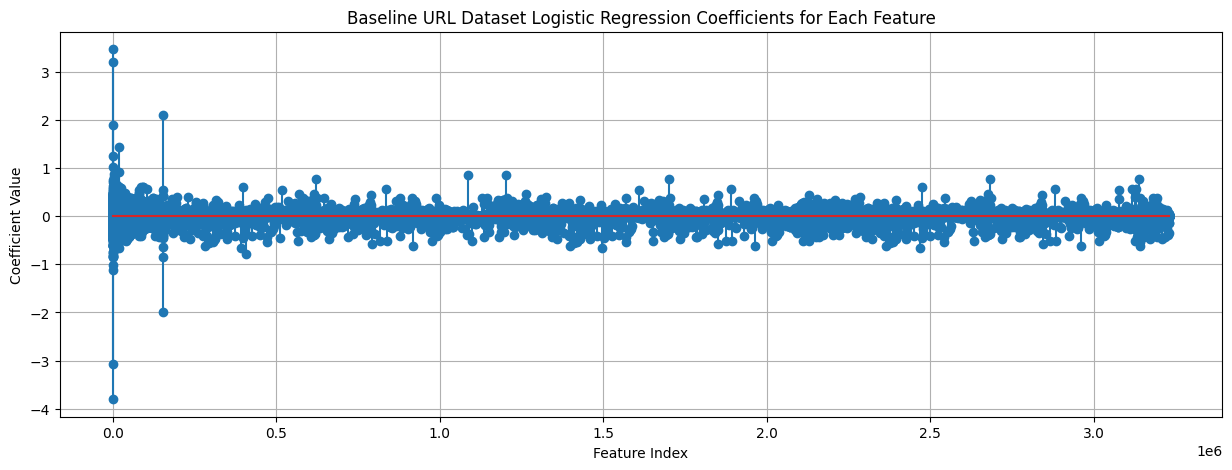

Features used as coefficients 58160
Execution time: 190.2126 seconds


In [21]:
import matplotlib.pyplot as plt
start = time.time()
#Plotting the coefficients to see how the model relies on many features
plt.figure(figsize=(15,5))
plt.stem(model_url_baseline.coef_[0])
plt.title('Baseline URL Dataset Logistic Regression Coefficients for Each Feature')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()

coefs_baseline = model_url_baseline.coef_[0]

print(f"Features used as coefficients {np.sum(coefs_baseline != 0)}")
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

Training regularized Logistic Regression model...
Regularized model training complete.
Execution time: 7.2906 seconds
Regularized Training Accuracy: 0.9874
Regularized Test Accuracy: 0.9794


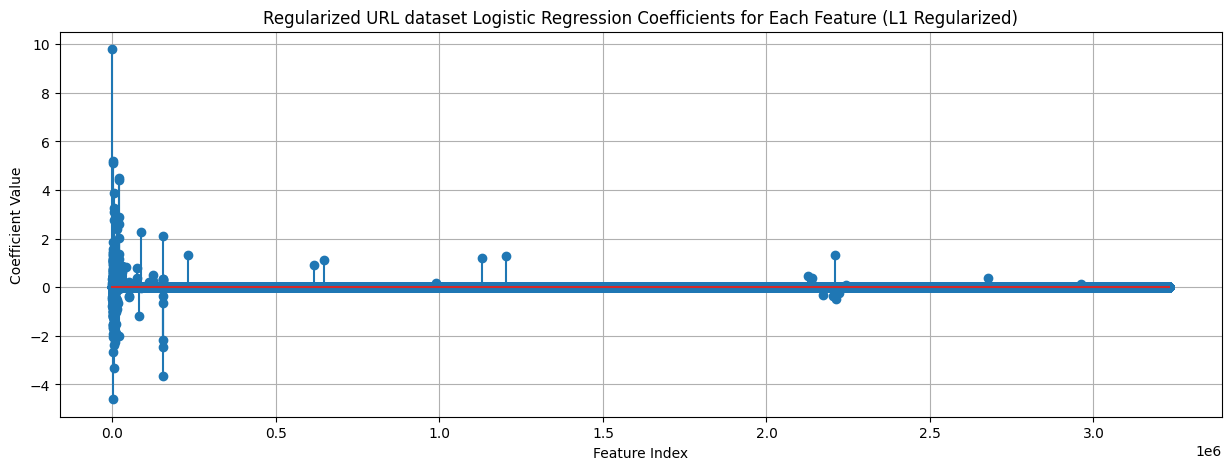

Features used as coefficients 370
Execution time: 141.4867 seconds


In [22]:
#Regularization with Lasso, which encourages sparsity in the coefficients
#Lasso corresponds to feature selection and reducing the impact of noisy features
#C parameter controls the inverse of regularization strength
model_regularized_url = LogisticRegression(solver='liblinear',penalty='l1',C=1.0, random_state=42, max_iter=1000)
start = time.time()
print("Training regularized Logistic Regression model...")
model_regularized_url.fit(X_train_url,y_train_url)
print("Regularized model training complete.")
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

#Evaluate regularized model on the training set
y_train_pred_reg_url=model_regularized_url.predict(X_train_url)
train_accuracy_reg_url = accuracy_score(y_train_url,y_train_pred_reg_url)
print(f"Regularized Training Accuracy: {train_accuracy_reg_url:.4f}")

#Evaluating regularized model on test set
y_test_pred_reg_url = model_regularized_url.predict(X_test_url)
test_accuracy_reg_url = accuracy_score(y_test_url,y_test_pred_reg_url)
print(f"Regularized Test Accuracy: {test_accuracy_reg_url:.4f}")

start = time.time()
#Plotting the coefficients of the regularized model
plt.figure(figsize=(15,5))
plt.stem(model_regularized_url.coef_[0])
plt.title('Regularized URL dataset Logistic Regression Coefficients for Each Feature (L1 Regularized)')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()

coefs_regularized = model_regularized_url.coef_[0]

print(f"Features used as coefficients {np.sum(coefs_regularized != 0)}")
end = time.time()

print(f"Execution time: {end - start:.4f} seconds")

In [23]:
#Evaluate the regularized model on day 1, 100, 120
start = time.time()
y_day1_pred_regularized = model_regularized_url.predict(X_day1_sparse)
accuracy_day1_regularized = accuracy_score(y_day1, y_day1_pred_regularized)
print(f"Regularized Model Accuracy on day 1.sv: {accuracy_day1_regularized:.4f}")
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

start = time.time()
y_day100_pred_regularized = model_regularized_url.predict(X_day100_sparse)
accuracy_day100_regularized = accuracy_score(y_day100, y_day100_pred_regularized)
print(f"Regularized Model Accuracy on day 100.sv: {accuracy_day100_regularized:.4f}")
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

start = time.time()
y_day120_pred_regularized = model_regularized_url.predict(X_day120_sparse)
accuracy_day120_regularized = accuracy_score(y_day120, y_day120_pred_regularized)
print(f"Regularized Model Accuracy on day 120.sv: {accuracy_day120_regularized:.4f}")
end = time.time()
print(f"Execution time: {end - start:.4f} seconds")

average=sum([test_accuracy_reg_url, accuracy_day1_regularized, accuracy_day100_regularized, accuracy_day120_regularized])/4
print(f"Regularized Model Accuracy Average: {average:.4f}")

Regularized Model Accuracy on day 1.sv: 0.9753
Execution time: 0.0201 seconds
Regularized Model Accuracy on day 100.sv: 0.9597
Execution time: 0.0163 seconds
Regularized Model Accuracy on day 120.sv: 0.9471
Execution time: 0.0119 seconds
Regularized Model Accuracy Average: 0.9654


In [24]:
print(f"Baseline Training Accuracy: {train_accuracy_url:.4f}")
print(f"Baseline Test Accuracy: {test_accuracy_url:.4f}")
print(f"Baseline Model Accuracy on day 1.sv: {accuracy_day1_baseline:.4f}")
print(f"Baseline Model Accuracy on day 100.sv: {accuracy_day100_baseline:.4f}")
print(f"Baseline Model Accuracy on day 120.sv: {accuracy_day120_baseline:.4f}")
averageb=sum([test_accuracy_url, accuracy_day1_baseline, accuracy_day100_baseline, accuracy_day120_baseline])/4
print(f"Baseline Model Accuracy Average: {averageb:.4f}")

print(f"Regularized Training Accuracy: {train_accuracy_reg_url:.4f}")
print(f"Regularized Test Accuracy: {test_accuracy_reg_url:.4f}")
print(f"Regularized Model Accuracy on day 1.sv: {accuracy_day1_regularized:.4f}")
print(f"Regularized Model Accuracy on day 100.sv: {accuracy_day100_regularized:.4f}")
print(f"Regularized Model Accuracy on day 120.sv: {accuracy_day120_regularized:.4f}")
averager=sum([test_accuracy_reg_url, accuracy_day1_regularized, accuracy_day100_regularized, accuracy_day120_regularized])/4
print(f"Regularized Model Accuracy Average: {averager:.4f}")

Baseline Training Accuracy: 0.9985
Baseline Test Accuracy: 0.9806
Baseline Model Accuracy on day 1.sv: 0.9747
Baseline Model Accuracy on day 100.sv: 0.9540
Baseline Model Accuracy on day 120.sv: 0.9354
Baseline Model Accuracy Average: 0.9612
Regularized Training Accuracy: 0.9874
Regularized Test Accuracy: 0.9794
Regularized Model Accuracy on day 1.sv: 0.9753
Regularized Model Accuracy on day 100.sv: 0.9597
Regularized Model Accuracy on day 120.sv: 0.9471
Regularized Model Accuracy Average: 0.9654


In [25]:
# Calculate and print percent errors for the Baseline Model
print("\n--- Baseline Model Percent Errors ---")
# (Training Accuracy - Test Accuracy) / Training Accuracy * 100
perror_baseline_test = abs((train_accuracy_url - test_accuracy_url) / train_accuracy_url) * 100
print(f"Percent Error (Training vs Test Accuracy): {perror_baseline_test:.4f}%")

perror_baseline_day1 = abs((train_accuracy_url - accuracy_day1_baseline) / train_accuracy_url) * 100
print(f"Percent Error (Training vs Day 1 Accuracy): {perror_baseline_day1:.4f}%")

perror_baseline_day100 = abs((train_accuracy_url - accuracy_day100_baseline) / train_accuracy_url) * 100
print(f"Percent Error (Training vs Day 100 Accuracy): {perror_baseline_day100:.4f}%")

perror_baseline_day120 = abs((train_accuracy_url - accuracy_day120_baseline) / train_accuracy_url) * 100
print(f"Percent Error (Training vs Day 120 Accuracy): {perror_baseline_day120:.4f}%")

perror_baseline_average = abs((train_accuracy_url - averageb) / train_accuracy_url) * 100
print(f"Percent Error (Training vs Average Baseline Accuracy): {perror_baseline_average:.4f}%")

# Calculate and print percent errors for the Regularized Model
print("\n--- Regularized Model Percent Errors ---")
perror_reg_test = abs((train_accuracy_reg_url - test_accuracy_reg_url) / train_accuracy_reg_url) * 100
print(f"Percent Error (Regularized Training vs Test Accuracy): {perror_reg_test:.4f}%")

perror_reg_day1 = abs((train_accuracy_reg_url - accuracy_day1_regularized) / train_accuracy_reg_url) * 100
print(f"Percent Error (Regularized Training vs Day 1 Accuracy): {perror_reg_day1:.4f}%")

perror_reg_day100 = abs((train_accuracy_reg_url - accuracy_day100_regularized) / train_accuracy_reg_url) * 100
print(f"Percent Error (Regularized Training vs Day 100 Accuracy): {perror_reg_day100:.4f}%")

perror_reg_day120 = abs((train_accuracy_reg_url - accuracy_day120_regularized) / train_accuracy_reg_url) * 100
print(f"Percent Error (Regularized Training vs Day 120 Accuracy): {perror_reg_day120:.4f}%")

perror_reg_average = abs((train_accuracy_reg_url - averager) / train_accuracy_reg_url) * 100
print(f"Percent Error (Regularized Training vs Average Regularized Accuracy): {perror_reg_average:.4f}%")


--- Baseline Model Percent Errors ---
Percent Error (Training vs Test Accuracy): 1.7884%
Percent Error (Training vs Day 1 Accuracy): 2.3805%
Percent Error (Training vs Day 100 Accuracy): 4.4585%
Percent Error (Training vs Day 120 Accuracy): 6.3170%
Percent Error (Training vs Average Baseline Accuracy): 3.7361%

--- Regularized Model Percent Errors ---
Percent Error (Regularized Training vs Test Accuracy): 0.8138%
Percent Error (Regularized Training vs Day 1 Accuracy): 1.2304%
Percent Error (Regularized Training vs Day 100 Accuracy): 2.8024%
Percent Error (Regularized Training vs Day 120 Accuracy): 4.0837%
Percent Error (Regularized Training vs Average Regularized Accuracy): 2.2326%


Limitations/Weaknesses of Logistic Regression Reevaluation

1. Computational Intensity
How long does it take for the model to be created?
This doesn't seem to be a major detriment to the time a model needs to be to be created. However, using 58160 features/coefficients took a longer time to create a plot  with only 370 coefficients with 126 seconds versus 119 seconds, which is signficant greater than 5%.
2. Overfitting
How many features does the model fit to?
The baseline uses 58160 data, which compared to an improved one could use less coefficients and receive better results, which would be more accurate to the rest of the data.
3. Poor Generalization
Is the training accuracy significantly higher than the test accuracy?
The baseline model is overfit with a signficiant error from the training accuracy to the Day 120 accuracy at 6.3170%. In considering the average of everything,it remains within 5% and it isn't as significant as the synthetic dataset. This could be because there are not specifically coefficients that produce huge noise and outliers, but do over time create the signficant difference.